# Visualize First LUNA16 Synthetic 2D Batch

This notebook loads one fold through `SyntheticLuna16DataModule` and displays the first training batch.

In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/src')

In [17]:
import matplotlib.pyplot as plt
import torch

from luna16_synthetic_2d.datamodule import SyntheticLuna16DataModule

In [18]:
fold = 0
batch_size = 8
image_size = [256, 384]

datamodule = SyntheticLuna16DataModule(
    synthetic_images_dir="/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/outputs/luna16_saliency_synthetic_gt",
    split_csv=None,
    splits_dir="/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/data/LUNA16_preprocessed/cv_splits",
    fold=fold,
    classes=["benign", "malignant"],
    train_split="train",
    val_split="val",
    test_split="test",
    image_size=image_size,
    batch_size=batch_size,
    num_workers=0,
)
datamodule.setup("fit")

print(f"train samples: {len(datamodule.train_dataset)}")
print(f"val samples: {len(datamodule.val_dataset)}")

train samples: 638
val samples: 79


In [19]:
images, labels, seriesuids = next(iter(datamodule.train_dataloader()))
images.shape, labels, seriesuids[:2]

(torch.Size([8, 3, 256, 384]),
 tensor([0, 1, 1, 1, 1, 1, 0, 1]),
 ('1.3.6.1.4.1.14519.5.2.1.6279.6001.129567032250534530765928856531',
  '1.3.6.1.4.1.14519.5.2.1.6279.6001.321935195060268166151738328001'))

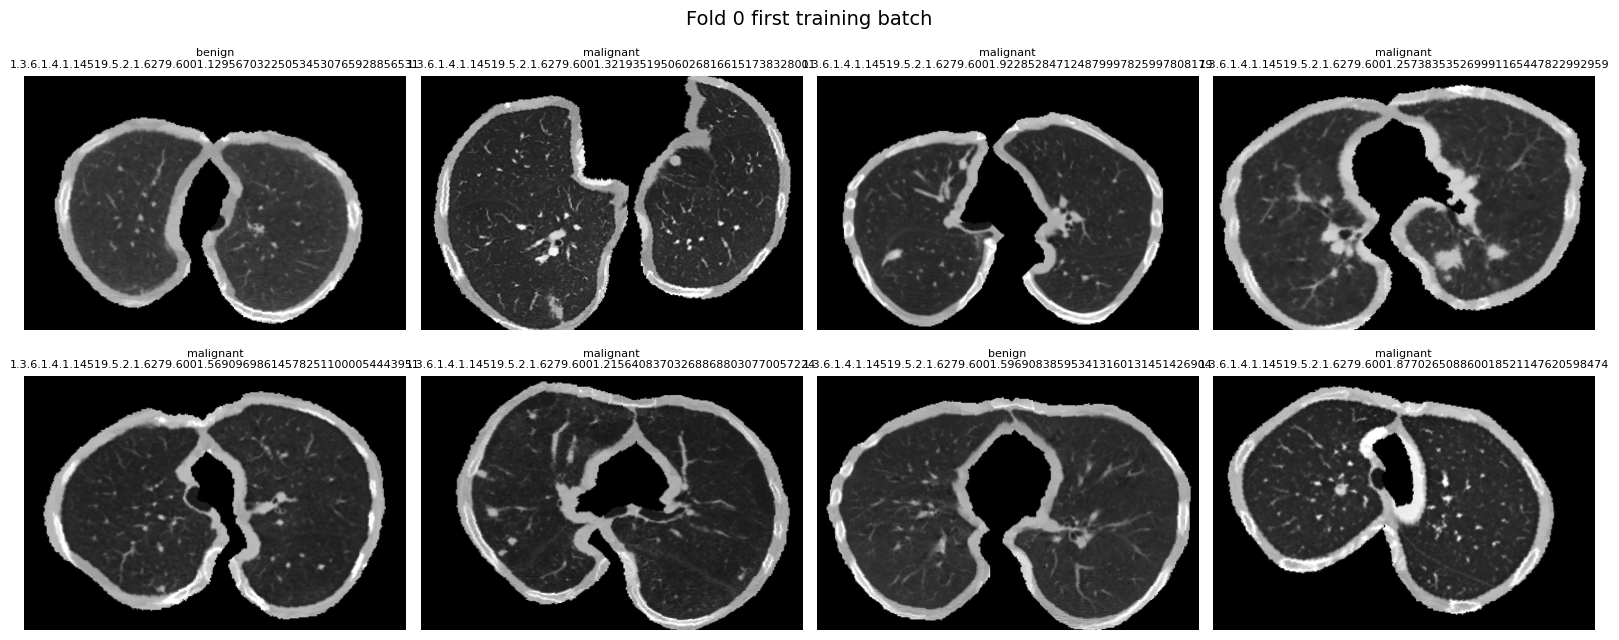

In [20]:
class_names = ["benign", "malignant"]

class MinMaxScale:
    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        min_value = tensor.amin()
        max_value = tensor.amax()
        scale = (max_value - min_value).clamp_min(1e-6)
        return (tensor - min_value) / scale


images = MinMaxScale()(images)

n = min(len(images), 8)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows), squeeze=False)

for ax in axes.ravel():
    ax.axis("off")

for idx in range(n):
    ax = axes.ravel()[idx]
    image = images[idx].detach().cpu()
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    label = int(labels[idx].item())
    ax.imshow(image)
    ax.set_title(f"{class_names[label]}\n{seriesuids[idx]}", fontsize=8)
    ax.axis("off")

fig.suptitle(f"Fold {fold} first training batch", fontsize=14)
plt.tight_layout()
plt.show()